# Google Play Store Analysis



## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download("vader_lexicon")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## 2. Load Datasets



In [4]:
apps = pd.read_csv("googleplaystore.csv")
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

print("Apps:", apps.shape)
print("Reviews:", reviews.shape)


Apps: (10841, 13)
Reviews: (64295, 5)


## 3. Clean Data Types

In [5]:
apps["Installs"] = pd.to_numeric(
    apps["Installs"].astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False),
    errors="coerce"
)

apps["Price"] = pd.to_numeric(
    apps["Price"].astype(str).str.replace("$", "", regex=False),
    errors="coerce"
)

apps["Rating"] = pd.to_numeric(apps["Rating"], errors="coerce")
apps[["Installs", "Price", "Rating"]].head()


,Installs,Price,Rating
0,10000.0,0.0,4.1
1,500000.0,0.0,3.9
2,5000000.0,0.0,4.7
3,50000000.0,0.0,4.5
4,100000.0,0.0,4.3


## 4. Apps by Category

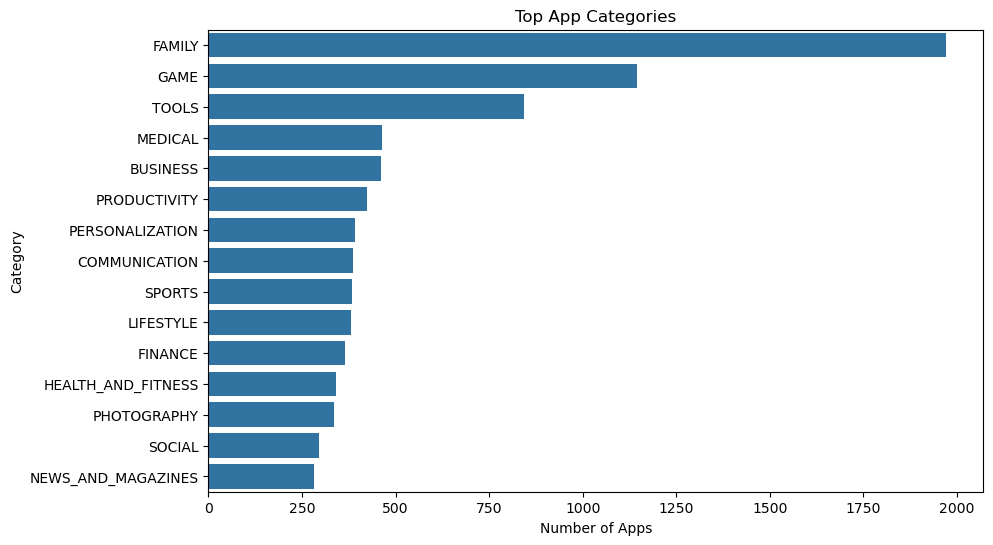

In [6]:
counts = apps["Category"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=counts.values, y=counts.index)
plt.title("Top App Categories")
plt.xlabel("Number of Apps")
plt.show()


## 5. Average Rating by Category

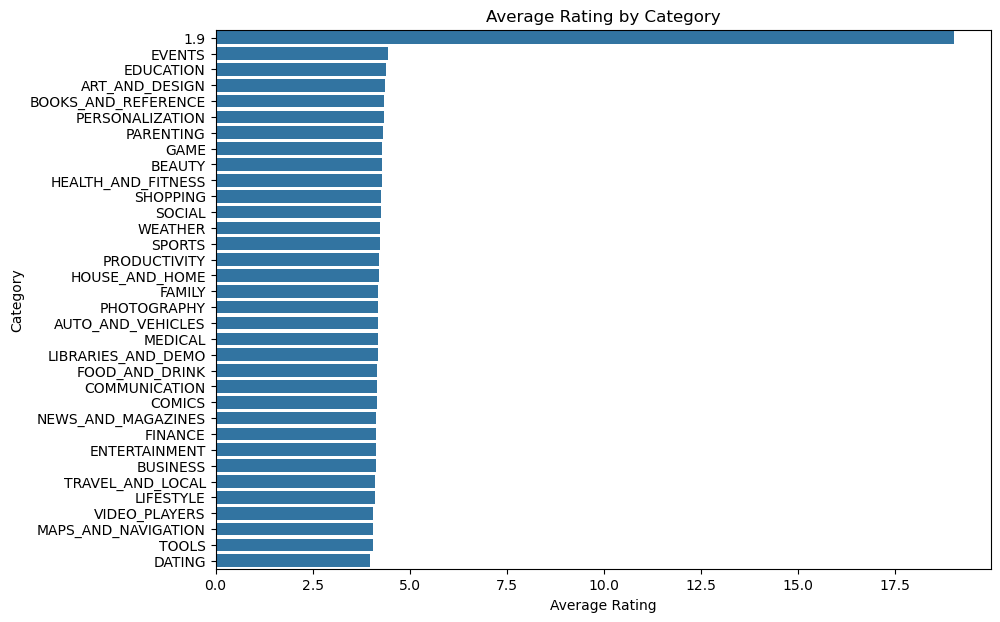

In [7]:
avg_rating = apps.groupby("Category")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(x=avg_rating.values, y=avg_rating.index)
plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.show()


## 6. Rating Distribution

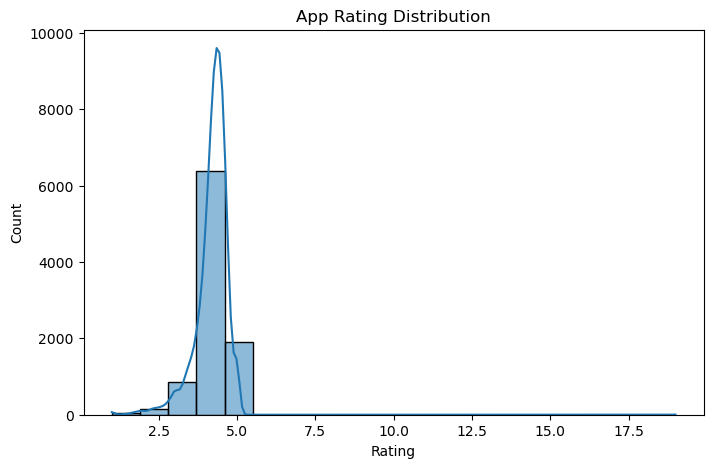

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(apps["Rating"].dropna(), bins=20, kde=True)
plt.title("App Rating Distribution")
plt.show()


## 7. Size vs Installs

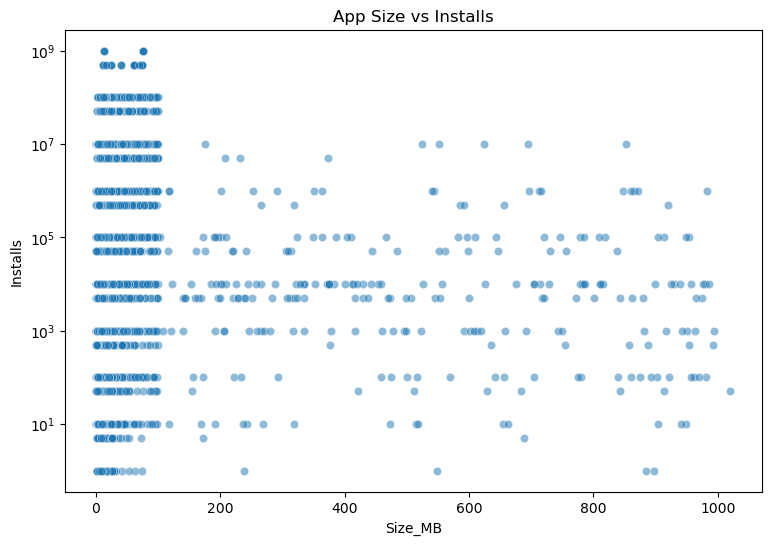

,Size_MB,Installs
Size_MB,1.000000,0.014753
Installs,0.014753,1.000000


In [9]:
apps["Size_MB"] = (
    apps["Size"].astype(str)
    .str.replace("M", "", regex=False)
    .str.replace("k", "", regex=False)
)
apps["Size_MB"] = pd.to_numeric(apps["Size_MB"], errors="coerce")

plot_data = apps.dropna(subset=["Size_MB", "Installs"])

plt.figure(figsize=(9,6))
sns.scatterplot(data=plot_data, x="Size_MB", y="Installs", alpha=0.5)
plt.yscale("log")
plt.title("App Size vs Installs")
plt.show()

plot_data[["Size_MB", "Installs"]].corr()


## 8. Free vs Paid

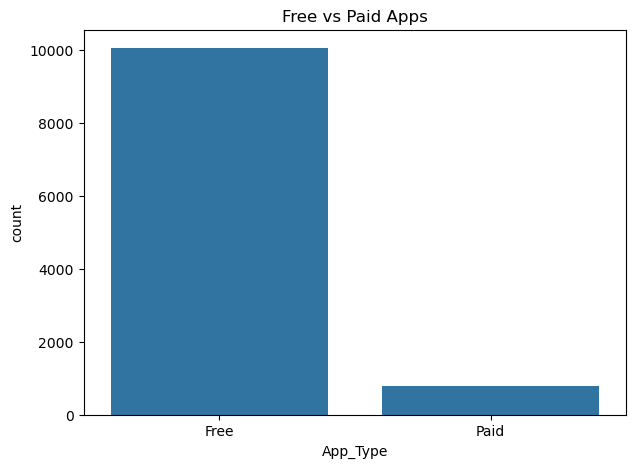

App_Type
Free    4.187901
Paid    4.266615
Name: Rating, dtype: float64

In [10]:
apps["App_Type"] = np.where(apps["Price"] > 0, "Paid", "Free")

plt.figure(figsize=(7,5))
sns.countplot(data=apps, x="App_Type")
plt.title("Free vs Paid Apps")
plt.show()

apps.groupby("App_Type")["Rating"].mean()


## 9. Price Distribution

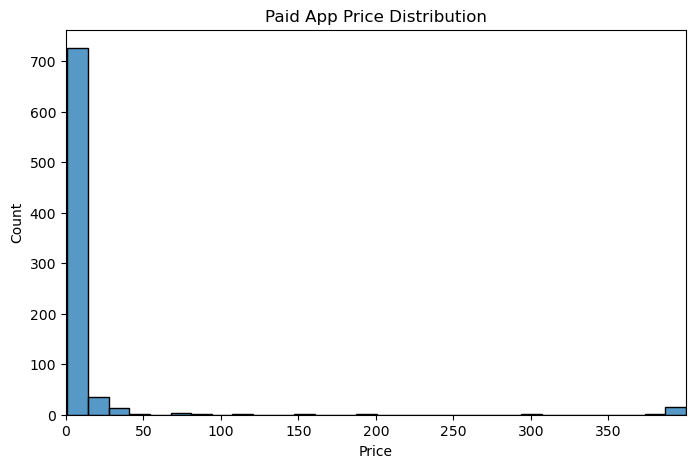

In [11]:
paid = apps[apps["Price"] > 0]

plt.figure(figsize=(8,5))
sns.histplot(paid["Price"], bins=30)
plt.xlim(0, paid["Price"].quantile(0.99))
plt.title("Paid App Price Distribution")
plt.show()


## 10. VADER Sentiment Analysis

In [12]:
reviews = reviews.dropna(subset=["Translated_Review"])

sia = SentimentIntensityAnalyzer()

reviews["Compound"] = reviews["Translated_Review"].astype(str).apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

reviews["Sentiment"] = pd.cut(
    reviews["Compound"],
    bins=[-1, -0.05, 0.05, 1],
    labels=["Negative", "Neutral", "Positive"]
)

reviews["Sentiment"].value_counts()


Sentiment
Positive    25526
Negative     7505
Neutral      4396
Name: count, dtype: int64

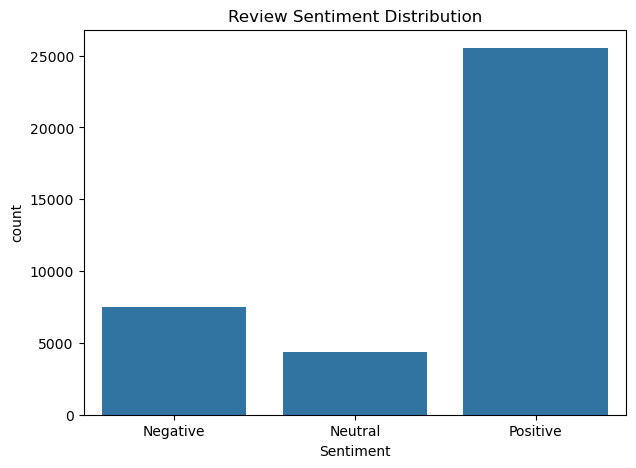

In [13]:
plt.figure(figsize=(7,5))
sns.countplot(data=reviews, x="Sentiment")
plt.title("Review Sentiment Distribution")
plt.show()


## 11. Sentiment by Category

In [14]:
sentiment_app = reviews.groupby("App")["Compound"].mean().reset_index()
app_category = apps[["App", "Category"]].drop_duplicates()

sentiment_category = sentiment_app.merge(
    app_category, on="App", how="left"
)

sentiment_category.groupby("Category")["Compound"].mean().sort_values(ascending=False).head(15)


Category
PARENTING              0.504054
COMICS                 0.486310
HEALTH_AND_FITNESS     0.476333
EVENTS                 0.454576
AUTO_AND_VEHICLES      0.450152
ART_AND_DESIGN         0.443430
FOOD_AND_DRINK         0.435971
EDUCATION              0.433762
FAMILY                 0.409607
GAME                   0.393267
MEDICAL                0.382828
PRODUCTIVITY           0.366918
BOOKS_AND_REFERENCE    0.360243
MAPS_AND_NAVIGATION    0.357410
LIBRARIES_AND_DEMO     0.356102
Name: Compound, dtype: float64